# 🔬 BioSLATE Project — Phase 2 & 3: Synthetic Lethal Target Discovery

**Author:** Faith Ogundimu  
**Date:** June 2025

**Notebook Purpose:**
This notebook sets the foundation for identifying synthetic lethal interactions in High-Grade Serous Ovarian Cancer (HGSOC) cell lines. Using gene effect scores from DepMap CRISPR screens (Chronos), we aim to determine which genes become essential when specific genomic biomarkers (e.g., BRCA1 deletion) are present. These biomarkers were defined through cross-validation between TCGA tumours and DepMap cell lines (Phase 1).

> **Context:** This analysis builds directly on the biomarker shortlists from Phase 1, where amplified and deleted genes were cross-validated between TCGA tumours and HGSOC cell lines.
> Here, we test whether these CNA biomarkers can stratify cell lines in a way that reveals context-specific gene dependencies.

### Objectives:
* Group HGSOC cell lines based on the presence or absence of validated CNA biomarkers (e.g., BRCA1 deletion).
* For each group, compare CRISPR gene effect scores to identify genes that are **synthetically lethal** only in biomarker-positive lines.
* Perform statistical tests (e.g., Welch’s t-test) to assess significance.
* Adjust for multiple testing using False Discovery Rate (FDR) correction.
* Prioritise biomarker–target pairs with strong effect sizes and high confidence for therapeutic relevance.


## Step 1A: DepMap Dataset Preprocessing
Take the DepMap dataset and filter to only keep the asses the data, understanding the Gene Effect format.

In [10]:
import pandas as pd

# read in file
crispr_df = pd.read_csv("/Users/faith/Documents/GitHub/bioslate-hgsoc-core/database_files/DepMap/CRISPRGeneEffect.csv", index_col=0)
# This will make the cell line names (i.e. 'ACH-000628', 'ACH-000974'), etc., become the row index (instead of just Row 0, Row 1, ...).

In [11]:
crispr_df

,A1BG (1),A1CF (29974),A2M (2),A2ML1 (144568),A3GALT2 (127550),A4GALT (53947),A4GNT (51146),AAAS (8086),AACS (65985),AADAC (13),...,ZWILCH (55055),ZWINT (11130),ZXDA (7789),ZXDB (158586),ZXDC (79364),ZYG11A (440590),ZYG11B (79699),ZYX (7791),ZZEF1 (23140),ZZZ3 (26009)
ACH-000001,-0.121964,0.042647,0.026102,-0.147614,-0.020425,0.184014,-0.076020,-0.097068,0.182759,-0.002365,...,-0.120536,0.107286,0.166390,0.262275,0.163876,-0.249508,0.053725,0.067986,0.136285,-0.438536
ACH-000004,-0.016484,-0.088500,-0.088198,-0.041225,-0.028074,-0.157206,0.280101,-0.106904,0.178125,0.149760,...,-0.192527,-0.324059,0.230377,0.087609,0.074897,0.054335,-0.330343,0.099067,0.274566,0.001871
ACH-000005,-0.184847,0.003300,0.160881,0.086224,-0.149315,-0.253837,0.167011,-0.101209,-0.129827,0.029143,...,-0.312827,-0.338023,-0.039700,-0.055349,-0.000367,-0.205605,-0.066032,-0.054518,0.035579,-0.150486
ACH-000007,-0.071921,-0.113717,0.082872,0.099633,-0.008378,-0.022310,0.014416,-0.184977,-0.173739,0.196363,...,-0.334843,-0.355499,-0.014183,0.230944,0.044628,-0.081863,-0.390748,-0.036547,-0.273129,-0.382723
ACH-000009,-0.019163,-0.134669,0.060323,0.076647,0.078922,-0.100243,0.047559,-0.136988,0.037759,0.093207,...,-0.299593,-0.194427,-0.027365,0.236591,-0.084224,-0.098271,-0.510495,0.052938,0.018623,-0.258353
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
ACH-002926,-0.107883,-0.101501,0.046677,0.096868,-0.118650,-0.065258,-0.064944,-0.175912,-0.044707,0.126244,...,-0.409541,-0.579376,0.038706,0.338610,-0.174379,-0.040264,-0.239763,0.065168,-0.144088,-0.334424
ACH-002928,-0.287606,-0.179101,-0.135824,-0.046579,-0.249888,-0.097376,0.070385,0.049444,-0.244937,0.058041,...,-0.095328,-0.440452,0.303500,0.097690,0.151790,0.039994,0.098240,-0.266654,-0.115108,-0.080421
ACH-003012,-0.145878,-0.004000,0.091933,0.191332,-0.065385,-0.134152,0.012353,-0.321012,0.001571,0.146177,...,-0.280119,-0.662673,-0.180936,0.169997,-0.036326,0.158702,-0.213281,-0.017884,-0.195395,-0.309021
ACH-003177,-0.038435,-0.055660,0.018989,0.117182,0.063397,0.049993,0.175520,-0.085752,0.078435,0.089513,...,-0.080700,-0.476797,-0.158375,-0.008999,-0.030058,-0.103513,-0.119234,-0.153744,0.032584,-0.536071


### What is the "CRISPR Gene Effect" (Chronos)?

- Each **value** reflects how essential a gene is for a given **cell line's survival**.
- **Lower scores** (closer to –1) = **higher dependency** (i.e. gene knockout causes cell death).
- **Score ~ 0** = knockout has little to no effect.
- Chronos is an updated model designed to better estimate **gene knockout effects** from CRISPR screens, especially in **non-dividing or slow-growing** cells.

| **Gene Effect Score** | **Interpretation** |
| --- | --- |
| ~–1.0 | Strong dependency |
| ~0.0 | No effect |
| > 0.0 | Possibly beneficial knock-out (rare) |

## Step 1B: Subsetting DepMap CNA Data to HGSOC Cell Lines

**Purpose:**  
This notebook isolates copy number alteration (CNA) data from DepMap for High-Grade Serous Ovarian Cancer (HGSOC) cell lines only. This is because the file contains CN info for multiple cell lines not just HGSOC.  

DepMap Context Viewer to see all HGSOC cell lines:  
https://depmap.org/portal/context/High-Grade%20Serous%20Ovarian%20Cancer

In [12]:
hgsoc_cell_lines = pd.read_csv("/Users/faith/Documents/GitHub/bioslate-hgsoc-core/database_files/DepMap/cell lines in High-Grade Serous Ovarian Cancer.csv")
# The first row is treated as the header (column names) by default. (explicit; header=0)

hgsoc_cell_lines

,Depmap Id,Cell Line,Primary Disease,Tumor Type
0,ACH-000132,JHOS2,Ovarian Epithelial Tumor,Primary
1,ACH-002183,OVMIU,Ovarian Epithelial Tumor,NaN
2,ACH-001151,OVCAR5,Ovarian Epithelial Tumor,Metastatic
3,ACH-000635,SNU119,Ovarian Epithelial Tumor,Metastatic
4,ACH-000430,TYKNU,Ovarian Epithelial Tumor,Primary
5,ACH-002140,HEY,Ovarian Epithelial Tumor,Primary
6,ACH-000103,CAOV4,Ovarian Epithelial Tumor,Metastatic
7,ACH-000001,NIHOVCAR3,Ovarian Epithelial Tumor,Metastatic
8,ACH-000256,COV318,Ovarian Epithelial Tumor,Metastatic
9,ACH-000542,HEYA8,Ovarian Epithelial Tumor,Metastatic


In [13]:
# Get the intersection of cell lines present in both hgsoc_cell_lines and crispr
valid_ids = hgsoc_cell_lines["Depmap Id"].isin(crispr_df.index) # returns boolean
shared_ids = hgsoc_cell_lines.loc[valid_ids, "Depmap Id"] # returns indexed list.

# Now use this list to filter crispr
crispr_filtered = crispr_df.loc[shared_ids]

In [14]:
# Keep only the entrez ID
crispr_filtered.columns = crispr_filtered.columns.str.extract(r"\((\d+)\)")[0].astype(str)

# ['ACH-000635', 'ACH-000409', 'ACH-000574', 'ACH-000617', 'ACH-000443'] not in crispr file.

### CRISPR File 

In [15]:
crispr_filtered

,1,29974,2,144568,127550,53947,51146,8086,65985,13,...,55055,11130,7789,158586,79364,440590,79699,7791,23140,26009
ACH-000132,-0.122873,0.072059,0.038849,0.039049,-0.209066,0.076330,-0.094047,-0.009645,-0.031795,0.202345,...,-0.131236,-0.471731,0.029672,0.012413,-0.127275,0.018842,-0.164656,-0.155827,-0.115392,-0.650192
ACH-002183,-0.245112,-0.053354,0.071037,0.337962,-0.109942,-0.013398,0.303089,0.046424,0.200121,0.492939,...,-0.405278,-0.548039,0.075445,-0.046378,-0.319488,-0.146330,-0.352998,-0.081459,-0.191924,-0.215067
ACH-001151,-0.102453,-0.077385,-0.019409,0.028298,-0.160307,-0.056900,0.039573,-0.268167,0.002770,0.096360,...,-0.119769,-0.217415,0.016761,0.170917,-0.044003,-0.095041,-0.187164,-0.083624,-0.176731,-0.417039
ACH-000430,-0.084244,0.058017,-0.053142,0.198323,-0.072941,-0.206886,0.122309,-0.018023,-0.105048,0.214323,...,-0.023189,-0.538709,0.027976,0.119626,-0.031476,-0.021702,-0.215309,-0.333313,-0.015074,-0.006619
ACH-002140,-0.104728,0.110308,-0.025987,0.257998,0.108899,-0.154841,0.001961,-0.214199,0.055091,0.245402,...,-0.665836,-0.157587,0.073392,-0.048359,-0.063494,-0.012150,-0.228079,-0.016597,-0.187425,-0.560568
ACH-000103,-0.294804,0.065371,-0.063194,0.072800,-0.072182,0.159779,0.236855,0.137420,-0.244539,0.331102,...,-0.269222,-0.593750,0.108921,-0.102701,-0.173919,0.045712,-0.208987,0.035390,-0.158814,0.033504
ACH-000001,-0.121964,0.042647,0.026102,-0.147614,-0.020425,0.184014,-0.076020,-0.097068,0.182759,-0.002365,...,-0.120536,0.107286,0.166390,0.262275,0.163876,-0.249508,0.053725,0.067986,0.136285,-0.438536
ACH-000256,-0.198217,-0.046660,0.050505,0.029620,-0.062260,-0.002114,0.278037,-0.293802,-0.109867,0.157249,...,-0.304890,-0.471835,-0.124134,0.080740,0.161809,0.089320,0.025617,-0.091058,0.117985,-0.217564
ACH-000542,-0.135195,-0.012998,0.106194,0.150954,0.033209,-0.006644,-0.015868,-0.542180,-0.093912,0.089950,...,-0.321037,-0.365938,0.045471,0.107203,-0.067005,0.014995,-0.359367,-0.094584,-0.216769,-0.449894
ACH-000696,-0.014307,-0.008415,0.023248,0.063404,-0.050467,-0.005701,-0.025869,-0.297252,-0.071535,0.081685,...,-0.179381,-0.542944,0.105737,-0.027614,-0.185295,-0.033858,-0.113058,-0.103185,-0.238914,-0.439584


In [16]:
crispr_filtered.to_csv("../streamlit_app/data/crispr_for_streamlit.csv")

## Step 2: Dataset Exploration
Based on preknown filters, assess how many genes pass this filter.

In [17]:
# Count how many genes have at least one cell line with effect size < –0.6
sig_in_at_least_one = (crispr_filtered < -0.6).any(axis=0).sum()

print(f"Number of genes with effect size < –0.6 in at least one cell line: {sig_in_at_least_one}")

Number of genes with effect size < –0.6 in at least one cell line: 2934


## Step 3: Group HGSOC cell lines based on the presence or absence of validated CNA biomarkers (e.g., BRCA1 deletion)

In [18]:
# Read in candidate deleted biomarkers.
cna_hgsoc_depmap = pd.read_csv("/Users/faith/Documents/GitHub/bioslate-hgsoc-core/results/cna_depmap_hgsoc.csv", index_col=0)

In [19]:
cna_hgsoc_depmap

,6009,54962,403253,55746,107984504,9601,106479964,730100,113523638,619448,...,8897,106480863,388181,106481503,100302218,53827,100873420,84910,106480139,106480076
ACH-000132,3.0,2.0,4.0,3.0,4.0,3.0,4.0,4.0,3.0,4.0,...,3.0,1.0,4.000000,4.00000,2.0,4.0,2.0,3.0,4.0,4.0
ACH-002183,2.0,2.0,2.0,3.0,2.0,2.0,2.0,2.0,2.0,2.0,...,2.0,3.0,2.000000,2.00000,2.0,2.0,2.0,2.0,2.0,2.0
ACH-001151,2.0,3.0,3.0,2.0,2.0,2.0,3.0,3.0,2.0,2.0,...,2.0,2.0,3.000000,2.00000,2.0,2.0,2.0,3.0,3.0,4.0
ACH-000635,4.0,2.0,3.0,4.0,4.0,4.0,3.0,3.0,3.0,2.0,...,2.0,3.0,2.000000,2.00000,4.0,4.0,2.0,4.0,3.0,3.0
ACH-000430,4.0,2.0,3.0,3.0,2.0,4.0,3.0,3.0,2.0,2.0,...,2.0,3.0,2.000000,2.00000,4.0,2.0,2.0,3.0,2.0,2.0
ACH-002140,1.0,3.0,4.0,3.0,4.0,1.0,4.0,4.0,4.0,4.0,...,3.0,3.0,3.000000,5.00000,2.0,4.0,3.0,4.0,5.0,5.0
ACH-000103,3.0,2.0,2.0,4.0,3.0,3.0,2.0,3.0,3.0,2.0,...,2.0,2.0,2.000000,2.00000,3.0,4.0,3.0,3.0,3.0,3.0
ACH-000001,3.0,4.0,4.0,4.0,6.0,3.0,4.0,3.0,4.0,4.0,...,4.0,4.0,2.000000,4.00000,3.0,6.0,5.0,3.0,4.0,6.0
ACH-000256,6.0,3.0,2.0,5.0,4.0,6.0,4.0,5.0,3.0,3.0,...,3.0,5.0,3.000000,3.00000,6.0,7.0,3.0,4.0,3.0,3.0
ACH-000542,2.0,3.0,5.0,3.0,5.0,2.0,4.0,4.0,4.0,5.0,...,3.0,3.0,3.000000,5.00000,2.0,4.0,4.0,4.0,5.0,5.0


In [20]:
# Read in candidate deleted biomarkers.
amp_biomarkers = pd.read_csv("/Users/faith/Documents/GitHub/bioslate-hgsoc-core/results/cross_val_amp_sig_genes.csv", index_col=1)

In [21]:
amp_biomarkers = amp_biomarkers.index.astype(str)
amp_biomarkers

Index(['10016', '1004', '10049', '10051', '10054', '10059', '10061', '10067',
       '10139', '10162',
       ...
       '9789', '9791', '9828', '9846', '9847', '9869', '9873', '9885', '9967',
       '9972'],
      dtype='object', name='Gene', length=522)

In [22]:
# Getting CNA info only for the cross validated biomarkers from Step 2.
# This will then be tested against the crispr gene effect file.

cna_hgsoc_depmap = cna_hgsoc_depmap.transpose()
cna_hgsoc_depmap_filtered = cna_hgsoc_depmap.loc[amp_biomarkers]

In [23]:
cna_hgsoc_depmap_filtered
# Genes are index

,ACH-000132,ACH-002183,ACH-001151,ACH-000635,ACH-000430,ACH-002140,ACH-000103,ACH-000001,ACH-000256,ACH-000542,...,ACH-000696,ACH-000574,ACH-000524,ACH-000116,ACH-000520,ACH-000278,ACH-000584,ACH-000013,ACH-001628,ACH-000443
Gene,,,,,,,,,,,,,,,,,,,,,
10016,3.0,2.0,3.0,6.0,3.0,4.0,6.000000,4.0,4.0,5.0,...,3.0,4.0,6.0,4.0,5.0,2.0,3.0,5.0,7.0,3.0
1004,3.0,2.0,2.0,3.0,3.0,4.0,4.000000,4.0,4.0,5.0,...,3.0,4.0,8.0,6.0,4.0,2.0,3.0,4.0,6.0,3.0
10049,5.0,2.0,2.0,4.0,4.0,1.0,3.000000,3.0,6.0,2.0,...,3.0,3.0,6.0,4.0,2.0,3.0,5.0,3.0,3.0,2.0
10051,7.0,3.0,4.0,4.0,3.0,6.0,3.000000,7.0,5.0,7.0,...,2.0,4.0,4.0,7.0,2.0,2.0,5.0,7.0,4.0,4.0
10054,4.0,2.0,2.0,4.0,2.0,4.0,4.000000,6.0,7.0,4.0,...,2.0,6.0,6.0,3.0,3.0,2.0,5.0,4.0,5.0,2.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9869,5.0,4.0,3.0,6.0,3.0,4.0,9.780668,3.0,5.0,4.0,...,2.0,4.0,5.0,3.0,3.0,3.0,4.0,2.5,5.0,3.0
9873,4.0,2.0,3.0,4.0,3.0,4.0,2.000000,8.0,5.0,4.0,...,3.0,4.0,4.0,4.0,3.0,4.0,5.0,8.0,4.0,3.0
9885,7.0,4.0,3.0,3.0,3.0,5.0,6.000000,6.0,7.0,6.0,...,3.0,4.0,7.0,2.0,3.0,2.0,5.0,5.0,5.0,3.0


### CNA File

In [24]:
cna_hgsoc_depmap_filtered = cna_hgsoc_depmap_filtered.transpose()
cna_hgsoc_depmap_filtered

Gene,10016,1004,10049,10051,10054,10059,10061,10067,10139,10162,...,9789,9791,9828,9846,9847,9869,9873,9885,9967,9972
ACH-000132,3.0,3.0,5.0,7.0,4.0,4.0,3.0,5.0,7.0,5.0,...,6.0,4.0,4.0,6.000000,6.0,5.000000,4.0,7.0,5.0,3.0
ACH-002183,2.0,2.0,2.0,3.0,2.0,2.0,2.0,4.0,3.0,2.0,...,2.0,2.0,2.0,2.000000,2.0,4.000000,2.0,4.0,2.0,2.0
ACH-001151,3.0,2.0,2.0,4.0,2.0,2.0,2.0,3.0,3.0,2.0,...,3.0,4.0,3.0,3.000000,2.0,3.000000,3.0,3.0,2.0,2.0
ACH-000635,6.0,3.0,4.0,4.0,4.0,3.0,4.0,5.0,3.0,4.0,...,4.0,6.0,4.0,5.000000,3.0,6.000000,4.0,3.0,3.0,3.0
ACH-000430,3.0,3.0,4.0,3.0,2.0,2.0,4.0,3.0,3.0,2.0,...,3.0,3.0,3.0,3.000000,2.0,3.000000,3.0,3.0,4.0,2.0
ACH-002140,4.0,4.0,1.0,6.0,4.0,6.0,1.0,4.0,5.0,6.0,...,4.0,7.0,4.0,4.000000,6.0,4.000000,4.0,5.0,3.0,3.0
ACH-000103,6.0,4.0,3.0,3.0,4.0,3.0,3.0,5.0,6.0,3.0,...,2.0,2.0,2.0,2.000000,3.0,9.780668,2.0,6.0,3.0,3.0
ACH-000001,4.0,4.0,3.0,7.0,6.0,5.0,3.0,6.0,6.0,3.0,...,4.0,4.0,8.0,13.413596,7.0,3.000000,8.0,6.0,3.0,3.0
ACH-000256,4.0,4.0,6.0,5.0,7.0,4.0,6.0,5.0,7.0,4.0,...,5.0,2.0,5.0,5.000000,3.0,5.000000,5.0,7.0,5.0,4.0
ACH-000542,5.0,5.0,2.0,7.0,4.0,6.0,2.0,4.0,6.0,6.0,...,4.0,8.0,4.0,5.000000,6.0,4.000000,4.0,6.0,3.0,4.0


## Synthetic Lethality Screen: Amplified Biomarkers vs CRISPR Dependencies

This code performs a biomarker-driven synthetic lethality screen using CRISPR dependency data across HGSOC cell lines.

### Key Steps

1. **Amplification Status Assignment**

   * For each amplified biomarker gene (based on `amp_threshold = 4`), label cell lines as either `"Amplified"` or `"WT"`.

2. **CRISPR Dependency Comparison**

   * For each biomarker:

     * Divide cell lines into Amplified vs WT groups.
     * For every CRISPR-targeted gene:

       * **Filter genes** to include only those with _at least one cell line_ showing a **strong dependency (effect size < –0.6)**.
       * Run **Welch’s t-test** comparing knockout scores between groups.
       * Compute **Cohen’s d effect size**.
       * Flag `OncogeneAddiction` if `Biomarker == TargetGene`.

3. **Multiple Testing Correction**

   * Apply **Benjamini–Hochberg FDR correction** within each biomarker’s comparisons.


In [25]:
from scipy.stats import ttest_ind
from statsmodels.stats.multitest import multipletests
import numpy as np
import pandas as pd

# Parameters
amp_threshold = 4.0  # Amplification cutoff for absolute CN
min_group_size = 3
effect_threshold = -0.6  # Strong dependency in at least one cell line

# --- Step 1: Generate CNA status matrix for amplified biomarkers only ---
status_dict = {}

for gene in amp_biomarkers:
    if gene in cna_hgsoc_depmap_filtered.columns:
        status_dict[f"{gene}_status"] = cna_hgsoc_depmap_filtered[gene].apply(
            lambda x: "Amplified" if x > amp_threshold else "WT"
        )

cna_status_df = pd.DataFrame(status_dict, index=cna_hgsoc_depmap_filtered.index)

# --- Step 2: Loop through biomarkers and perform CRISPR comparisons ---
results = []

for biomarker in amp_biomarkers:
    biomarker_col = f"{biomarker}_status"
    if biomarker_col not in cna_status_df.columns:
        continue

    amp_lines = cna_status_df[cna_status_df[biomarker_col] == "Amplified"].index
    wt_lines = cna_status_df[cna_status_df[biomarker_col] == "WT"].index

    amp_lines = [line for line in amp_lines if line in crispr_filtered.index]
    wt_lines = [line for line in wt_lines if line in crispr_filtered.index]

    if len(amp_lines) < min_group_size or len(wt_lines) < min_group_size:
        continue

    for gene in crispr_filtered.columns:
        # New filter: keep gene only if at least one cell line shows strong dependency
        if not (crispr_filtered[gene] < effect_threshold).any():
            continue

        group_amp = crispr_filtered.loc[amp_lines, gene].dropna()
        group_wt = crispr_filtered.loc[wt_lines, gene].dropna()

        if len(group_amp) < min_group_size or len(group_wt) < min_group_size:
            continue

        t_stat, p_val = ttest_ind(group_amp, group_wt, equal_var=False)
        pooled_sd = np.sqrt(((group_amp.std(ddof=1)**2 + group_wt.std(ddof=1)**2) / 2))
        effect_size = (group_amp.mean() - group_wt.mean()) / pooled_sd if pooled_sd > 0 else np.nan

        results.append({
            "Biomarker": biomarker,
            "TargetGene": gene,
            "OncogeneAddiction": biomarker == gene,
            "T-stat": t_stat,
            "P-value": p_val,
            "EffectSize": effect_size,
            "n_Amplified": len(group_amp),
            "n_WT": len(group_wt),
            "MeanEffect_Amplified": group_amp.mean(),
            "MeanEffect_WT": group_wt.mean()
        })

# --- Step 3: Convert to DataFrame ---
results_df = pd.DataFrame(results)

# --- Step 4: FDR correction (per biomarker) ---
results_df["FDR"] = results_df.groupby("Biomarker")["P-value"].transform(
    lambda p: multipletests(p, method="fdr_bh")[1]
)

# --- Step 5: Save ---
results_df.to_csv("../results/synthetic_lethality_screen.csv", index=False)

In [26]:
results_df.shape

(1486950, 11)

In [27]:
# Count number of oncogene addictions.
oncogene_addict_counts = results_df["OncogeneAddiction"].sum()
oncogene_addict_counts

# "OncogeneAddiction" is already a Boolean column.
# .sum() on a Boolean Series counts how many True values exist.

183

## Step 4: Filter Most Significant Hits

In [28]:
import pandas as pd

# Load results
results_df = pd.read_csv("../results/synthetic_lethality_screen.csv")

# Filter 1: P-value < 0.05
pval_hits = results_df[results_df["P-value"] < 0.05]
pval_hits.to_csv("../results/other/significant_synthetic_hits_pval.csv", index=False)

# Filter 2: FDR < 0.05
fdr_hits = results_df[results_df["FDR"] < 0.05]
fdr_hits.to_csv("../results/other/significant_synthetic_hits_fdr.csv", index=False)

# Filter 3: Strong & significant SL hits
# Criteria: FDR < 0.05 AND EffectSize < 0
sl_hits_strong = results_df[
    (results_df["FDR"] < 0.05) &
    (results_df["EffectSize"] < 0)
]
sl_hits_strong.to_csv("../results/strong_synthetic_lethal_hits.csv", index=False)

# Filter 4: Selective hits only (WT not too essential)
# Criteria: MeanEffect_WT > -1 to exclude pan-essential genes
sl_hits_selective = sl_hits_strong[sl_hits_strong["MeanEffect_WT"] > -1]
sl_hits_selective.to_csv("../results/selective_synthetic_lethal_hits.csv", index=False)

# Print summary
print(f"P-value < 0.05: {len(pval_hits)} hits")
print(f"FDR < 0.05: {len(fdr_hits)} hits")
print(f"Strong SL hits (FDR < 0.05 & EffectSize < 0): {len(sl_hits_strong)} hits")
print(f"Selective SL hits (excluding WT-essential genes): {len(sl_hits_selective)} hits")

P-value < 0.05: 81451 hits
FDR < 0.05: 163 hits
Strong SL hits (FDR < 0.05 & EffectSize < 0): 88 hits
Selective SL hits (excluding WT-essential genes): 54 hits


## Step 5: Add HGNC Gene Symbols to SL Results

This step maps Entrez Gene IDs in the `Biomarker` and `TargetGene` columns to their official HGNC gene symbols using the `gene_with_protein_product.txt` reference file.

The HGNC names are inserted directly beside each ID column in both:
- `strong_synthetic_lethal_hits.csv`
- `selective_synthetic_lethal_hits.csv`

Updated files are saved with `_with_HGNC` suffix in the `../results/` folder.


In [29]:
import pandas as pd

# Load your result files
sl_hits_strong = pd.read_csv("../results/strong_synthetic_lethal_hits.csv")
sl_hits_selective = pd.read_csv("../results/selective_synthetic_lethal_hits.csv")

# Load the HGNC mapping file
hgnc_df = pd.read_csv("../database_files/gene_with_protein_product.txt", sep="\t")

# Build a mapping: Entrez ID (as string) → HGNC symbol
entrez_to_symbol = dict(zip(hgnc_df["entrez_id"].astype(str), hgnc_df["symbol"]))

# Function to insert HGNC symbols beside original columns
def insert_hgnc_columns(df):
    df.insert(loc=df.columns.get_loc("Biomarker") + 1,
              column="Biomarker_HGNC",
              value=df["Biomarker"].apply(lambda x: entrez_to_symbol.get(str(x))))
    
    df.insert(loc=df.columns.get_loc("TargetGene") + 1,
              column="TargetGene_HGNC",
              value=df["TargetGene"].apply(lambda x: entrez_to_symbol.get(str(x))))
    return df

# Apply to both DataFrames
sl_hits_strong = insert_hgnc_columns(sl_hits_strong)
sl_hits_selective = insert_hgnc_columns(sl_hits_selective)

# Save updated files
sl_hits_strong.to_csv("../results/strong_synthetic_lethal_hits_with_HGNC.csv", index=False)
sl_hits_selective.to_csv("../results/selective_synthetic_lethal_hits_with_HGNC.csv", index=False)

/var/folders/09/0r9l07110lg5nj9ndgsx9kl80000gn/T/ipykernel_90506/967590705.py:8: DtypeWarning: Columns (35,38,45,48,49) have mixed types. Specify dtype option on import or set low_memory=False.
  hgnc_df = pd.read_csv("../database_files/gene_with_protein_product.txt", sep="\t")


## Step 6: Visualizations

### Volcano Plot vs Heatmap Summary

| Feature           | Volcano Plot                                             | Heatmap                                                         |
| ----------------- | -------------------------------------------------------- | --------------------------------------------------------------- |
| **What it shows** | Strength + significance of each biomarker–target pair    | Global dependency patterns across biomarkers                    |
| **X-axis**        | Effect size (Cohen’s d)                                  | Biomarker gene (columns)                                        |
| **Y-axis**        | –log₁₀(FDR)                                              | Target gene (rows)                                              |
| **Highlights**    | Top hits: SL pairs with large negative effects + low FDR | Repeatedly essential genes, co-dependencies, oncogene addiction |
| **Use case**      | Identify top hits per biomarker                          | Spot patterns, redundancies, shared vulnerabilities             |



### Volcano Plot: Visualising Strength vs Significance of SL Hits

The volcano plot helps visualise **synthetic lethal interactions** by combining:

- **Effect size** (Cohen’s d): how much more lethal a gene knockout is in amplified vs wild-type lines
- **Statistical significance** (FDR): confidence in the result

#### What it shows:
- **X-axis**: Effect size (negative values = stronger synthetic lethality)
- **Y-axis**: –log₁₀(FDR) (higher = more statistically significant)
- Each point = one biomarker–target gene pair

#### Why it's important:
- Highlights **top SL hits**: genes with **strong negative effects** and **low FDR**
- Easily distinguishes:
  - True positives (top-left)
  - Noise (bottom center)
  - Oncogene addiction
  
- Fast way to prioritise genes for validation or drug targeting


/var/folders/09/0r9l07110lg5nj9ndgsx9kl80000gn/T/ipykernel_90506/3745896628.py:35: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()
/Library/Frameworks/Python.framework/Versions/3.10/lib/python3.10/site-packages/IPython/core/pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


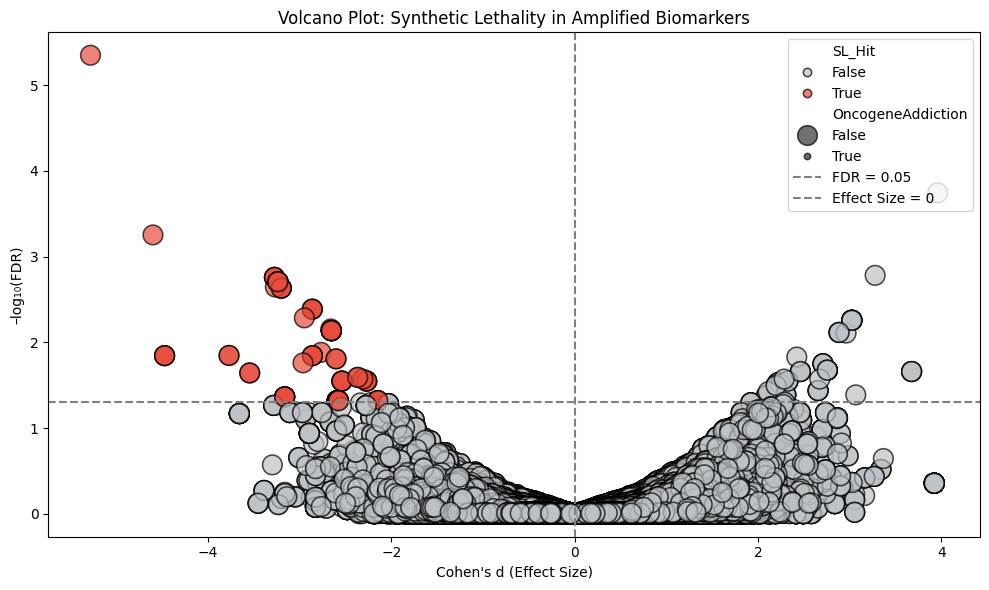

In [30]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Load results
results_df = pd.read_csv("../results/synthetic_lethality_screen.csv")

# Add significance threshold
results_df["–log10(FDR)"] = -np.log10(results_df["FDR"] + 1e-10)  # avoid log(0)

# Define SL hit
results_df["SL_Hit"] = (results_df["EffectSize"] < 0) & (results_df["FDR"] < 0.05)
results_df["OncogeneAddiction"] = results_df["Biomarker"] == results_df["TargetGene"]

# Plot
plt.figure(figsize=(10, 6))
sns.scatterplot(
    data=results_df,
    x="EffectSize",
    y="–log10(FDR)",
    hue="SL_Hit",
    size="OncogeneAddiction",
    sizes=(20, 200),
    palette={True: "#e74c3c", False: "#bdc3c7"},
    alpha=0.7,
    edgecolor="black"
)
plt.axhline(y=-np.log10(0.05), linestyle="--", color="gray", label="FDR = 0.05")
plt.axvline(x=0, linestyle="--", color="gray", label="Effect Size = 0")
plt.xlabel("Cohen's d (Effect Size)")
plt.ylabel("–log₁₀(FDR)")
plt.title("Volcano Plot: Synthetic Lethality in Amplified Biomarkers")
plt.legend()
plt.tight_layout()
plt.show()

### 2. **Heatmap**

#### **Purpose:**

Show **patterns of gene dependencies across multiple biomarkers**, helping identify:

* Repeated vulnerabilities (e.g. “this gene is SL with many amplifications”)
* Gene modules or pathway-level effects

---

#### **What It Shows:**

| Axis        | What’s Shown                                              |
| ----------- | --------------------------------------------------------- |
| **Rows**    | Target genes                                              |
| **Columns** | Amplified biomarkers                                      |
| **Cells**   | Cohen’s d, Mean effect in amplified lines, or –log₁₀(FDR) |

---

#### **What You Can Spot:**

* **Horizontal bands** = genes that are SL with many biomarkers
* **Vertical bands** = biomarkers with many dependencies
* **Dark cells** = strong SL effects (e.g., `EffectSize < 0`)

In [39]:
### add hgnc column to complete synthetic lethal screen csv

import pandas as pd

# Load your result files
sl_screen = pd.read_csv("../results/synthetic_lethality_screen.csv")

# Load the HGNC mapping file
hgnc_df = pd.read_csv("../database_files/gene_with_protein_product.txt", sep="\t")

# Build a mapping: Entrez ID (as string) → HGNC symbol
entrez_to_symbol = dict(zip(hgnc_df["entrez_id"].astype(str), hgnc_df["symbol"]))

# Function to insert HGNC symbols beside original columns
def insert_hgnc_columns(df):
    df.insert(loc=df.columns.get_loc("Biomarker") + 1,
              column="Biomarker_HGNC",
              value=df["Biomarker"].apply(lambda x: entrez_to_symbol.get(str(x))))
    
    df.insert(loc=df.columns.get_loc("TargetGene") + 1,
              column="TargetGene_HGNC",
              value=df["TargetGene"].apply(lambda x: entrez_to_symbol.get(str(x))))
    return df

# Apply to both DataFrames
sl_screen = insert_hgnc_columns(sl_screen)

# Save updated files
sl_screen.to_csv("../results/synthetic_lethality_screen_with_HGNC.csv", index=False)


/var/folders/09/0r9l07110lg5nj9ndgsx9kl80000gn/T/ipykernel_90506/855254808.py:9: DtypeWarning: Columns (35,38,45,48,49) have mixed types. Specify dtype option on import or set low_memory=False.
  hgnc_df = pd.read_csv("../database_files/gene_with_protein_product.txt", sep="\t")


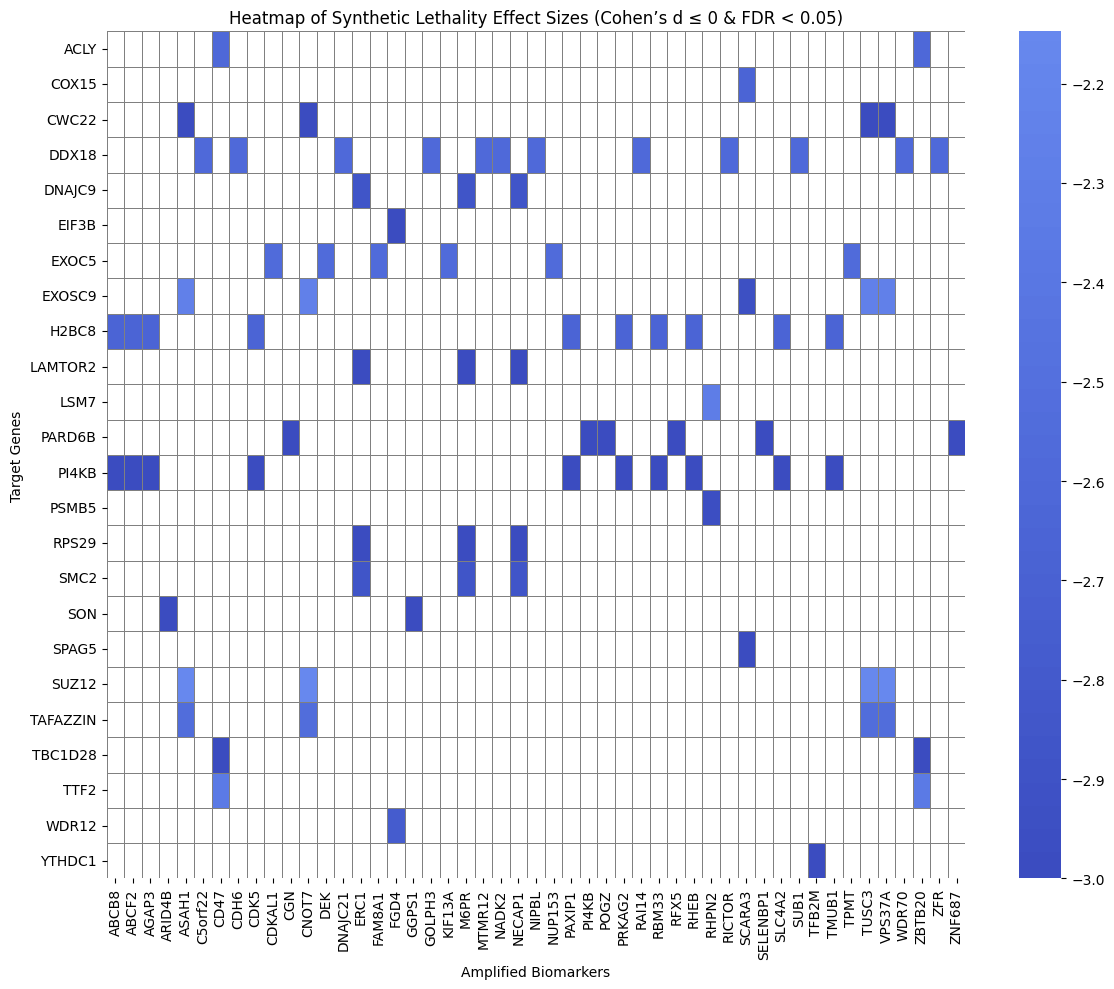

In [40]:
import seaborn as sns
import matplotlib.pyplot as plt

# Load results
results_df = pd.read_csv("../results/synthetic_lethality_screen_with_HGNC.csv")

# Pivot: rows = target genes, cols = biomarkers, values = Effect Size
heatmap_df = results_df[
    (results_df["EffectSize"] < 0) & (results_df["FDR"] < 0.05)
].pivot(index="TargetGene_HGNC", columns="Biomarker_HGNC", values="EffectSize")

# Optional: cap extreme values
capped = heatmap_df.clip(-3, 0)

# Plot heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(capped, cmap="coolwarm", center=0, linewidths=0.5, linecolor="gray")
plt.title("Heatmap of Synthetic Lethality Effect Sizes (Cohen’s d ≤ 0 & FDR < 0.05)")
plt.xlabel("Amplified Biomarkers")
plt.ylabel("Target Genes")
plt.tight_layout()
plt.show()

### 3. Boxplots: Gene Effect Scores in Wild-Type vs Amplified Cell Lines

#### Purpose:
For each biomarker–target gene pair from the synthetic lethality screen, we visualise the gene effect scores (e.g. from CRISPR or RNAi screens) in:

- **Amplified** cell lines (with biomarker gene amplification)
- **Wild-type** cell lines (no amplification)

#### What This Shows:
- Whether gene dependency is significantly stronger in amplified vs. wild-type backgrounds
- How consistent the synthetic lethal signal is across individual cell lines

In [35]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import os

# --- Load data ---
results_df = pd.read_csv("../results/selective_synthetic_lethal_hits_with_HGNC.csv")
cna_df = pd.read_csv("../results/cna_depmap_hgsoc.csv", index_col=0)
amp_biomarkers_df = pd.read_csv("../results/cross_val_amp_sig_genes.csv")

# Ensure crispr_filtered is defined
try:
    crispr_filtered
except NameError:
    print("'crispr_filtered' is not loaded in memory. Please load it before running.")
    raise

# --- Ensure all IDs are strings ---
id_cols = ["Biomarker", "TargetGene"]
for col in id_cols:
    results_df[col] = results_df[col].astype(str).str.strip()
    cna_df.columns = cna_df.columns.astype(str).str.strip()
    crispr_filtered.columns = crispr_filtered.columns.astype(str).str.strip()

amp_biomarkers_df["Gene"] = amp_biomarkers_df["Gene"].astype(str).str.strip()

# --- Parameters ---
amp_threshold = 4.0
min_group_size = 3
output_dir = "../figures/boxplots_SL_pairs/"
os.makedirs(output_dir, exist_ok=True)

# --- Build CNA status matrix ---
amp_biomarkers = amp_biomarkers_df["Gene"].unique()
status_dict = {}

for gene in amp_biomarkers:
    if gene in cna_df.columns:
        status_dict[f"{gene}_status"] = cna_df[gene].apply(
            lambda x: "Amplified" if x > amp_threshold else "WT"
        )

cna_status_df = pd.DataFrame(status_dict, index=cna_df.index)

# --- Counters for debugging ---
total_pairs = 0
skipped_missing_columns = 0
skipped_small_groups = 0
plotted = 0

print(f"Expecting to plot {len(results_df)} pairs from selective_synthetic_lethal_hits_with_HGNC.csv")

# --- Plot each pair ---
for _, row in results_df.iterrows():
    biomarker = row["Biomarker"]
    target = row["TargetGene"]
    biomarker_hgnc = row["Biomarker_HGNC"]
    target_hgnc = row["TargetGene_HGNC"]
    total_pairs += 1

    biomarker_status_col = f"{biomarker}_status"
    if biomarker_status_col not in cna_status_df.columns or target not in crispr_filtered.columns:
        skipped_missing_columns += 1
        continue

    # Define CNA groups
    amp_lines = cna_status_df[cna_status_df[biomarker_status_col] == "Amplified"].index
    wt_lines = cna_status_df[cna_status_df[biomarker_status_col] == "WT"].index

    amp_lines = [line for line in amp_lines if line in crispr_filtered.index]
    wt_lines = [line for line in wt_lines if line in crispr_filtered.index]

    if len(amp_lines) < min_group_size or len(wt_lines) < min_group_size:
        skipped_small_groups += 1
        continue

    data = pd.DataFrame({
        "GeneEffect": pd.concat([
            crispr_filtered.loc[amp_lines, target],
            crispr_filtered.loc[wt_lines, target]
        ]),
        "CNA_Status": ["Amplified"] * len(amp_lines) + ["WT"] * len(wt_lines)
    }).dropna()

    # --- Plot ---
    plt.figure(figsize=(6, 5))
    sns.boxplot(data=data, x="CNA_Status", y="GeneEffect", hue="CNA_Status",
                palette={"Amplified": "#e74c3c", "WT": "#3498db"}, legend=False)
    sns.stripplot(data=data, x="CNA_Status", y="GeneEffect", color="black", alpha=0.4, jitter=True, size=4)
    plt.title(f"{target_hgnc} Dependency in {biomarker_hgnc}-Amplified vs WT", fontsize=11)
    plt.ylabel("CRISPR Gene Effect Score")
    plt.xlabel("CNA Status")
    plt.axhline(0, linestyle="--", color="gray", linewidth=1)
    plt.tight_layout()

    filename = f"{biomarker_hgnc}__{target_hgnc}.png".replace("/", "_")
    plt.savefig(os.path.join(output_dir, filename), dpi=300)
    plt.close()
    plotted += 1

# --- Debug summary ---
print(f"Total pairs in file: {total_pairs}")
print(f"Skipped (missing biomarker or target gene): {skipped_missing_columns}")
print(f"Skipped (group size < {min_group_size}): {skipped_small_groups}")
print(f"Boxplots saved: {plotted}")


Expecting to plot 54 pairs from selective_synthetic_lethal_hits_with_HGNC.csv
Total pairs in file: 54
Skipped (missing biomarker or target gene): 0
Skipped (group size < 3): 0
Boxplots saved: 54


## Boxplot Filtering: What Gets Skipped

This codes filters and skips `(Biomarker, TargetGene)` pairs based on several quality and relevance criteria. Only pairs that pass **all conditions below** are visualised.

1. FDR ≥ 0.05  
**Why it’s skipped:**
The synthetic lethality interaction is not statistically significant. These are excluded to avoid false positives.

2. Pan-essential Targets (Mean WT Effect ≤ –1)  
**Why it’s skipped:**
If a gene is highly essential even in wild-type (non-amplified) cell lines, it's likely not selectively lethal in the amplified condition. These are not biologically interesting for targeted therapy.

3. Missing Data  
**Why it’s skipped:**  
Either:

* The biomarker is not present in the CNA dataset, or
* The target gene is missing from the CRISPR dependency dataset.

4. No Strong Dependency Observed  
**Why it’s skipped:**
If no cell line has a gene effect score < –0.6 for the target, there's no evidence of selective vulnerability.

5. Too Few Cell Lines  
**Why it’s skipped:**
If there are fewer than 3 cell lines in either the amplified or WT group, boxplots are not statistically meaningful and are excluded.

---
#### Summary

Each pair is evaluated against all five conditions. If it fails **any one**, it is skipped from visualisation. Debug counters track the number skipped for each reason, helping ensure transparency and reproducibility.

Let me know if you’d like to log the skipped pairs into a CSV for further inspection.
